# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [1]:
#1. Clean the data and perform some EDA and visualization to get to know the data set.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

#LOAD THE DATA
df=pd.read_csv('/content/airbnb_hw.csv')
print(df.head())
print(df.info())

#CLEAN the data
df = df.drop_duplicates()
# Clean the Price column
# Drop ID and text columns that won't help
df = df.drop(columns=['Host Id', 'Name'])
# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Convert Host Since to numeric because its a sentence how
df['Host_Since'] = pd.to_datetime(df['Host Since'], errors='coerce')
df['Host_Years'] = (pd.Timestamp.today() - df['Host_Since']).dt.days / 365
df = df.drop(columns=['Host Since'])

# Convert Price to numeric by remocing the dollar sign and comma
df['Price'] = df['Price'].replace({'\$':'', ',':''}, regex=True).astype(float)

# Fill missing numeric values to avoid errors in thelunear regression later
numeric_cols = ['Review Scores Rating (bin)', 'Zipcode', 'Beds', 'Review Scores Rating']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df = df.drop(columns=['Host_Since'])
#drop NA to avoid error
df=df.dropna()

#EDA can drscribe then maek histrograms and KDE plits
print(df.describe())

# Histograms
df.hist(figsize=(12,10))
plt.show()

for col in df.select_dtypes(include=np.number).columns:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()



<>:29: SyntaxWarning: invalid escape sequence '\$'
<>:29: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_6651/3813200879.py:29: SyntaxWarning: invalid escape sequence '\$'
  df['Price'] = df['Price'].replace({'\$':'', ',':''}, regex=True).astype(float)


FileNotFoundError: [Errno 2] No such file or directory: '/content/airbnb_hw.csv'

In [ ]:
#2 transform the variables
# One-hot encode categorical variables
#Create dummies for categorical columns (except Price)
categorical_cols = ['Neighbourhood', 'Property Type', 'Room Type']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)



In [ ]:
# Split features and target
target = 'Price'
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
#4 put test data aside and build some linear models on training set
model = LinearRegression()

print(df.dtypes)
model.fit(X_train, y_train)

# Predictions
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

# Metrics
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, test_preds)

print("Simple Model:")
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Train R2:", train_r2)
print("Test R2:", test_r2)

# 1. Example: Beds + Number Of Reviews
X_train_simple1 = X_train[['Beds', 'Number Of Reviews']]
X_test_simple1  = X_test[['Beds', 'Number Of Reviews']]

# 2. Beds + Number Of Reviews + Review Scores Rating
X_train_simple2 = X_train[['Beds', 'Number Of Reviews', 'Review Scores Rating (bin)']]
X_test_simple2  = X_test[['Beds', 'Number Of Reviews', 'Review Scores Rating (bin)']]

# 3. All numeric features
X_train_simple3 = X_train.copy()
X_test_simple3  = X_test.copy()

# Step 6: Put models in a dictionary for iteration
models = {
    'Simple1': (X_train_simple1, X_test_simple1),
    'Simple2': (X_train_simple2, X_test_simple2),
    'Simple3': (X_train_simple3, X_test_simple3)
}

# Step 7: Fit models and evaluate
for name, (X_tr, X_te) in models.items():
    lr = LinearRegression()
    lr.fit(X_tr, y_train)

    train_preds = lr.predict(X_tr)
    test_preds  = lr.predict(X_te)

    print(f"\n{name}:")
    print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_preds)))
    print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_preds)))
    print("Train R2:", r2_score(y_train, train_preds))
    print("Test R2:", r2_score(y_test, test_preds))

Review Scores Rating (bin)       float64
Zipcode                          float64
Beds                             float64
Number of Records                  int64
Number Of Reviews                  int64
Price                            float64
Review Scores Rating             float64
Host_Years                       float64
Neighbourhood_Brooklyn              bool
Neighbourhood_Manhattan             bool
Neighbourhood_Queens                bool
Neighbourhood_Staten Island         bool
Property Type_Bed & Breakfast       bool
Property Type_Boat                  bool
Property Type_Bungalow              bool
Property Type_Cabin                 bool
Property Type_Camper/RV             bool
Property Type_Castle                bool
Property Type_Chalet                bool
Property Type_Condominium           bool
Property Type_Dorm                  bool
Property Type_House                 bool
Property Type_Hut                   bool
Property Type_Lighthouse            bool
Property Type_Lo

My simple model #3 appeared to perform the best. This model was fit on all numeric features. While R^2 were low for all this had the best test R^2 of 0.2193. Low R^2 likely indicates nonlinearities

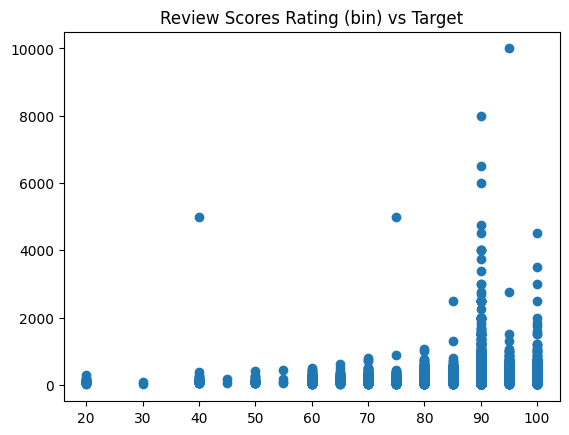

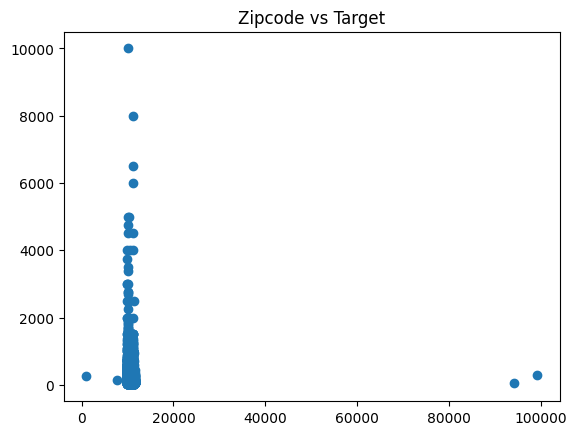

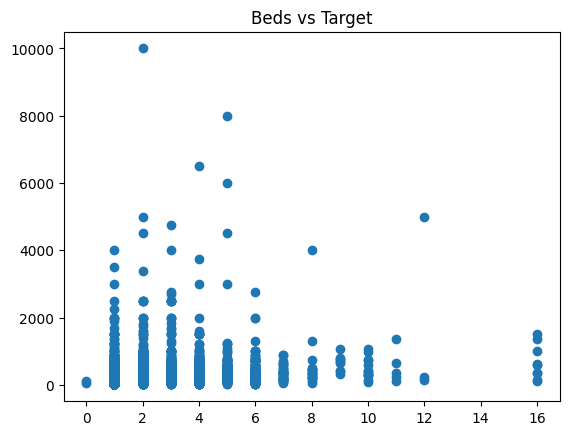

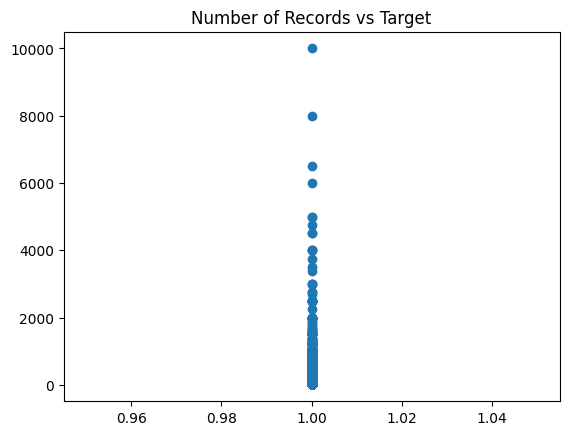

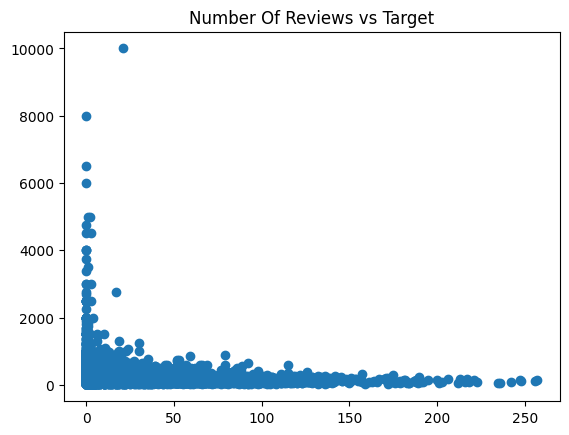

In [ ]:
#Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
for col in X_train.columns[:5]:  # limit to first few to avoid overload
    plt.scatter(X_train[col], y_train)
    plt.title(f"{col} vs Target")
    plt.show()

These plots reveal that there are significant non-linearities. If these predictors were linear with resepct to the target variable we would expect to see the points rougly form a line. In this example the points either form streaks down at specific values or they cluster at one end in a seemingly random way.

In [ ]:
#6 Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and  𝑅2  on the training and test sets. How does the more complex model your build compare to the simpler ones?

X_train_trans = X_train.copy()
X_test_trans = X_test.copy()

# Log transform skewed variables (example)
for col in X_train_trans.select_dtypes(include=np.number).columns:
    X_train_trans[col] = np.log1p(X_train_trans[col])
    X_test_trans[col] = np.log1p(X_test_trans[col])

# Refit model
model2 = LinearRegression()
model2.fit(X_train_trans, y_train)

train_preds2 = model2.predict(X_train_trans)
test_preds2 = model2.predict(X_test_trans)

train_rmse2 = np.sqrt(mean_squared_error(y_train, train_preds2))
test_rmse2 = np.sqrt(mean_squared_error(y_test, test_preds2))

train_r22 = r2_score(y_train, train_preds2)
test_r22 = r2_score(y_test, test_preds2)

print("\nComplex Model:")
print("Train RMSE:", train_rmse2)
print("Test RMSE:", test_rmse2)
print("Train R2:", train_r22)
print("Test R2:", test_r22)


Complex Model:
Train RMSE: 178.72267353220195
Test RMSE: 173.63869674429037
Train R2: 0.18705132015647363
Test R2: 0.21679248939303752
